# Preprocessing dan Training Model 1 (Delay Predictor)

## Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/delay_predictor_dataset.csv')
df = df.drop(columns='color')
print(df.info())
print(df.shape)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 226230 entries, 0 to 226229
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   bus_code      226230 non-null  str    
 1   trip_id       226230 non-null  str    
 2   gps_datetime  226230 non-null  str    
 3   location      226230 non-null  str    
 4   dtd           226230 non-null  float64
 5   corridor      226230 non-null  object 
 6   longitude     226230 non-null  float64
 7   latitude      226230 non-null  float64
 8   speed         226230 non-null  float64
 9   course        226230 non-null  int64  
 10  hour          226230 non-null  int64  
 11  day_of_week   226230 non-null  int64  
dtypes: float64(4), int64(3), object(1), str(4)
memory usage: 20.7+ MB
None
(226230, 12)


C:\Users\Wahfi\AppData\Local\Temp\ipykernel_15240\802117021.py:1: DtypeWarning: Columns (0: corridor) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/delay_predictor_dataset.csv')


,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,hour,day_of_week
0,DMR 5049,5.002,2019-11-26 14:08:04,"5-18,5-15",0.095727,5,106.866287,-6.22349,22.0,339,14,1
1,DMR 5049,5.002,2019-11-26 14:08:34,"5-18,5-15",0.232111,5,106.865562,-6.22185,30.0,339,14,1
2,DMR 5049,5.002,2019-11-26 14:09:04,"5-18,5-15",0.397415,5,106.864670,-6.21988,31.0,332,14,1
3,DMR 5049,5.002,2019-11-26 14:09:29,"5-18,5-15",0.550144,5,106.864128,-6.21793,35.0,349,14,1
4,DMR 5049,5.002,2019-11-26 14:10:04,"5-18,5-15",0.751485,5,106.863029,-6.21551,28.0,308,14,1


In [3]:
df.isna().sum()

bus_code        0
trip_id         0
gps_datetime    0
location        0
dtd             0
corridor        0
longitude       0
latitude        0
speed           0
course          0
hour            0
day_of_week     0
dtype: int64

In [4]:
(df['speed'] < 1.0).value_counts()

speed
False    146544
True      79686
Name: count, dtype: int64

Buang kolom color karena tidak bernilai untuk model, selain itu ada temuan yang terlewat saat EDA yakni kolom speed dengan value < 1.0 sebanyak 79.686 baris (35%). Baris dengan speed mendekati 0 akan menghasilkan actual_eta yang ekstrem atau error division by zero saat hitung delay_minutes (dtd / speed * 60). Meskipun ada kemungkinan bus sedang berhenti di halte atau traffic stop. Oleh karena itu, cek dulu persebaran datanya 

<Axes: xlabel='speed', ylabel='Count'>

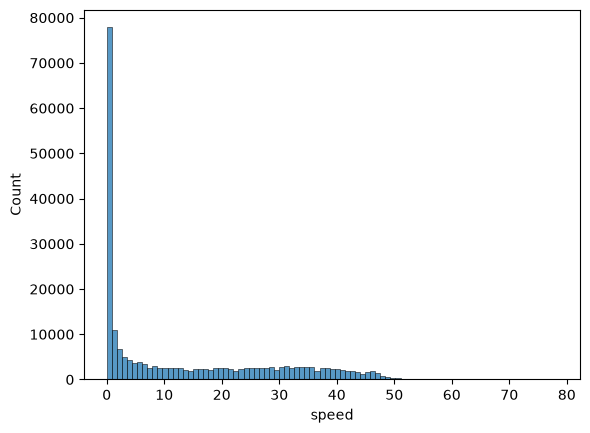

In [5]:
sns.histplot(data=df['speed'])

Spike besar di 0–2 km/h yang jumlahnya ~78.000+ baris. Dalam kondisi tersebut bus memang berhenti di halte, traffic light, macet dan bukan glitch. Masalahnya bukan di data, tapi di formula delay:

actual_eta = dtd / speed * 60

Speed = 0 membuat division by zero. Speed = 0.5 membuat delay jadi ribuan menit yang membuatnya menjadi outlier palsu.

Untuk masalah ini, solusi yang diambil adalah dengan clip speed minimum dengan set floor misalnya di angka 3 km/h. Sehingga bus yang benar-benar macet total (speed=0) diperlakukan sama dengan bus yang merangkak 3 km/h. 

In [6]:
clip_speed=df['speed'] < 3.0
print(clip_speed.shape[0])
clip_speed.describe()

226230


count     226230
unique         2
top        False
freq      129066
Name: speed, dtype: object

Sebagai percobaan, clip speed ke 3 km/h dan didapatkan hasil 97.164 baris yang terkena clip (42.9%). Target baris yang kena clip idealnya di bawah 40% agar justifikasi clip tidak lebih besar dari data aslinya saat ini masih di atas 40%, sekarang coba ke 1.5 km/h

In [7]:
(df['speed'] < 1.5).sum()

np.int64(85818)

Hasilnya 85.818 baris yang terkena clip (37.9%), di bawah 40%. Threshold finalnya menjadi 1.5 km/h, sehingga kecepatan minimum bus yang masih dianggap bergerak secara fisik adalah 1.5 km/h, di bawah itu praktis stasioner (berhenti di halte atau traffic stop total).

In [8]:
df['speed_clipped'] = df['speed'].clip(lower=1.5)
df['estimated_eta'] = df['dtd'] / 50 * 60
df['actual_eta'] = df['dtd'] / df['speed_clipped'] * 60
df['delay_minutes'] = df['actual_eta'] - df['estimated_eta']


In [9]:
df['delay_minutes'].describe()


count    226230.000000
mean          9.339014
std          13.300674
min          -0.346791
25%           0.310804
50%           1.583895
75%          14.952007
max          38.789408
Name: delay_minutes, dtype: float64

<Axes: >

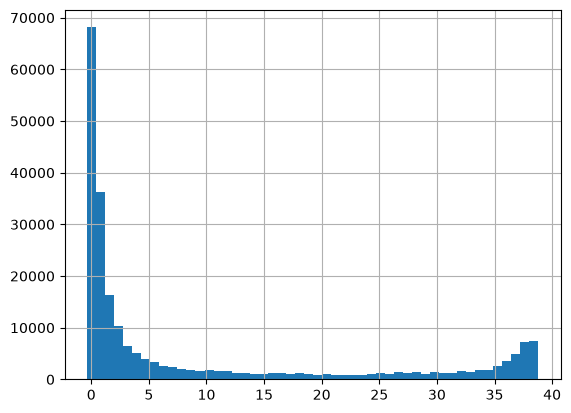

In [10]:
df['delay_minutes'].hist(bins=50)

In [11]:
df[df['delay_minutes'] > 35]['dtd'].describe()

count    25295.000000
mean         0.961416
std          0.025240
min          0.902087
25%          0.942919
50%          0.966333
75%          0.982754
max          0.999727
Name: dtd, dtype: float64

In [12]:
conditions = [(df['delay_minutes'] < 3.0), (df['delay_minutes'] > 3.0)]
choices = ['OnTime', 'Delayed']

df['status'] = np.select(conditions, choices, default='Unknown')

In [13]:
df['status'].value_counts()

status
OnTime     132772
Delayed     93458
Name: count, dtype: int64

In [14]:
df[df['status'] == 'Severe']['delay_minutes'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: delay_minutes, dtype: float64

### Augmentasi Dataset

In [ ]:
augmented_dfs = []

for day in range(7):
    for hour in range(6, 23):
        if day == 1 and 14 <= hour <= 17:
            continue
            
        is_weekend = (day >= 5)
        is_peak_hour = (6 <= hour <= 9) or (16 <= hour <= 19)
        
        if is_peak_hour:
            weights = df['dtd'] + 1e-6
            df_sample = df.sample(frac=0.1, weights=weights, random_state=(day * 100 + hour)).copy()
            speed_multiplier = np.random.uniform(0.5, 0.75, size=len(df_sample))

        elif is_weekend:
            df_sample = df.sample(frac=0.1, random_state=(day * 100 + hour)).copy()
            speed_multiplier = np.random.uniform(1.1, 1.3, size=len(df_sample))

        else:
            df_sample = df.sample(frac=0.1, random_state=(day * 100 + hour)).copy()
            speed_multiplier = np.random.uniform(0.9, 1.1, size=len(df_sample))
            
        df_sample['day_of_week'] = day
        df_sample['hour'] = hour
        
        new_speed = df_sample['speed'] * speed_multiplier
        df_sample['speed_clipped'] = new_speed.clip(lower=1.5, upper=80.0)
        df_sample['speed'] = new_speed 
        
        df_sample['estimated_eta'] = (df_sample['dtd'] / 50) * 60
        df_sample['actual_eta'] = (df_sample['dtd'] / df_sample['speed_clipped']) * 60
        df_sample['delay_minutes'] = df_sample['actual_eta'] - df_sample['estimated_eta']
        
        sample_conditions = [
            (df_sample['delay_minutes'] < 3.0),
            (df_sample['delay_minutes'] > 3.0)
        ]
        df_sample['status'] = np.select(sample_conditions, choices, default='Unknown')
        
        augmented_dfs.append(df_sample)

df_aug = pd.concat(augmented_dfs, ignore_index=True)

In [ ]:
print(f"TOTAL BARIS DATA:")
print(f"    - Data Asli      : {len(df):,} baris")
print(f"    - Data Sintetis  : {len(df_aug):,} baris")
print(f"    - Rasio Ekspansi : {len(df_aug)/len(df):.2f}x lipat data asli")
print("-" * 60)

df_syn_peak = df_aug[(df_aug['day_of_week'] < 5) & 
                               ((df_aug['hour'].between(6, 9)) | (df_aug['hour'].between(16, 19)))]

df_syn_off = df_aug[(df_aug['day_of_week'] < 5) & 
                              ~((df_aug['hour'].between(6, 9)) | (df_aug['hour'].between(16, 19)))]

df_syn_wend = df_aug[df_aug['day_of_week'] >= 5]

print(f"STATISTIK KECEPATAN (speed_clipped) - KM/JAM:")
stats_speed = pd.DataFrame({
    'Data Asli (Selasa Sore)': df['speed_clipped'].describe(),
    'Sintetis Weekday Peak': df_syn_peak['speed_clipped'].describe(),
    'Sintetis Weekday Off-Peak': df_syn_off['speed_clipped'].describe(),
    'Sintetis Weekend': df_syn_wend['speed_clipped'].describe()
})
print(stats_speed.round(2))
print("-" * 60)

print(f"STATISTIK DELAY (delay_minutes) - MENIT:")
stats_delay = pd.DataFrame({
    'Data Asli (Selasa Sore)': df['delay_minutes'].describe(),
    'Sintetis Weekday Peak': df_syn_peak['delay_minutes'].describe(),
    'Sintetis Weekday Off-Peak': df_syn_off['delay_minutes'].describe(),
    'Sintetis Weekend': df_syn_wend['delay_minutes'].describe()
})
stats_delay.loc['min'] = [df['delay_minutes'].min(), df_syn_peak['delay_minutes'].min(), df_syn_off['delay_minutes'].min(), df_syn_wend['delay_minutes'].min()]
stats_delay.loc['max'] = [df['delay_minutes'].max(), df_syn_peak['delay_minutes'].max(), df_syn_off['delay_minutes'].max(), df_syn_wend['delay_minutes'].max()]
print(stats_delay.round(2))
print("-" * 60)

print(f"DISTRIBUSI TARGET LABEL (status) - PERSENTASE (%):")
def get_status_pct(df):
    return df['status'].value_counts(normalize=True).mul(100).round(2)

status_dist = pd.DataFrame({
    'Data Asli': get_status_pct(df),
    'Syn Weekday Peak': get_status_pct(df_syn_peak),
    'Syn Weekday Off-Peak': get_status_pct(df_syn_off),
    'Syn Weekend': get_status_pct(df_syn_wend)
}).fillna(0) 
print(status_dist)
print("="*60)

In [17]:
df_final = pd.concat([df] + augmented_dfs, ignore_index=True)
df_final = df_final.sample(frac=1.0, random_state=42).reset_index(drop=True)

In [18]:
df_final.head()

,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,hour,day_of_week,speed_clipped,estimated_eta,actual_eta,delay_minutes,status
0,SAF 113,8.001,2019-11-26 15:45:10,"8-15,8-16",0.586449,8,106.764427,-6.168595,0.300000,332,15,1,1.500000,0.703739,23.457960,22.754221,Delayed
1,PPD 0323,4.D0067,2019-11-26 17:07:28,"4-12,4-13",0.969992,4,106.854584,-6.199020,0.000000,229,7,0,1.500000,1.163990,38.799680,37.635690,Delayed
2,TJ 0326,11.V201,2019-11-26 15:48:08,"11-3,11-2",0.017514,11,106.939525,-6.213882,5.500000,1,15,1,5.500000,0.021017,0.191063,0.170046,OnTime
3,MYS 17034,6.002,2019-11-26 15:54:46,"6-13,6-12",0.728932,6,106.832162,-6.232398,2.214087,213,9,3,2.214087,0.874718,19.753481,18.878762,Delayed
4,PPD 0261,5.C030,2019-11-26 14:52:24,"7-7,7-6",0.093377,7,106.865898,-6.262930,0.000000,212,22,5,1.500000,0.112052,3.735068,3.623016,Delayed


## Training 

In [19]:
from sklearn.preprocessing import LabelEncoder

cols_to_keep = ['hour', 'day_of_week', 'corridor', 'dtd', 'delay_minutes', 'status']
df_model = df_final[cols_to_keep].copy()

le = LabelEncoder()
df_model['corridor'] = le.fit_transform(df_model['corridor'].astype(str))
print(df_model.info())
print(df_model.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 2827875 entries, 0 to 2827874
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   hour           int64  
 1   day_of_week    int64  
 2   corridor       int64  
 3   dtd            float64
 4   delay_minutes  float64
 5   status         str    
dtypes: float64(2), int64(3), str(1)
memory usage: 129.4 MB
None
   hour  day_of_week  corridor       dtd  delay_minutes   status
0    15            1        14  0.586449      22.754221  Delayed
1     7            0         8  0.969992      37.635690  Delayed
2    15            1         2  0.017514       0.170046   OnTime
3     9            3        10  0.728932      18.878762  Delayed
4    22            5        11  0.093377       3.623016  Delayed


In [20]:
from sklearn.model_selection import train_test_split

X = df_model[['hour', 'day_of_week', 'corridor', 'dtd']]
y_reg = df_model['delay_minutes']
y_clf = df_model['status']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(X_train.shape, X_test.shape)
print(y_clf_train.value_counts(normalize=True))
print(y_clf_test.value_counts(normalize=True))

(2262300, 4) (565575, 4)
status
Delayed    0.507016
OnTime     0.492984
Name: proportion, dtype: float64
status
Delayed    0.507015
OnTime     0.492985
Name: proportion, dtype: float64


In [21]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report

# Regression
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)

y_reg_pred = rf_reg.predict(X_test)
print("R²:", r2_score(y_reg_test, y_reg_pred))
print("MAE:", mean_absolute_error(y_reg_test, y_reg_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)))

# Classification
rf_clf = rf_clf = RandomForestClassifier(
    n_estimators=100,          
    max_depth=12,              
    min_samples_split=20,      
    max_features='sqrt',       
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_clf_train)

y_clf_pred = rf_clf.predict(X_test)
print(classification_report(y_clf_test, y_clf_pred))

importances = pd.Series(
    rf_clf.feature_importances_,
    index=['hour', 'day_of_week', 'corridor', 'dtd']
).sort_values(ascending=False)
print(importances)

R²: 0.9522196900789354
MAE: 1.3069230931750804
RMSE: 3.1668196182850474
              precision    recall  f1-score   support

     Delayed       0.76      0.72      0.74    286755
      OnTime       0.73      0.77      0.75    278820

    accuracy                           0.74    565575
   macro avg       0.74      0.74      0.74    565575
weighted avg       0.74      0.74      0.74    565575

dtd            0.844170
corridor       0.097671
hour           0.055297
day_of_week    0.002862
dtype: float64


In [22]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

lgbm_clf.fit(X_train, y_clf_train)
y_lgbm_pred = lgbm_clf.predict(X_test)
print(classification_report(y_clf_test, y_lgbm_pred))

[LightGBM] [Info] Number of positive: 1115278, number of negative: 1147022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 2262300, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492984 -> initscore=-0.028065
[LightGBM] [Info] Start training from score -0.028065
              precision    recall  f1-score   support

     Delayed       0.75      0.75      0.75    286755
      OnTime       0.75      0.74      0.75    278820

    accuracy                           0.75    565575
   macro avg       0.75      0.75      0.75    565575
weighted avg       0.75      0.75      0.75    565575



In [ ]:
import joblib

joblib.dump(rf_reg, 'model1_delay_regressor.pkl', compress=3)
joblib.dump(lgbm_clf, 'model1_status_classifier.pkl')
joblib.dump(le, 'model1_corridor_encoder.pkl')


In [1]:
model1_config = {
    'baseline_speed': 50,
    'speed_clip_lower': 1.5,
    'delay_thresholds': {'Late': 5, 'Severe': 15},
    'binary_classes': ['OnTime', 'Delayed'],
    'features_regressor': ['hour', 'day_of_week', 'corridor', 'dtd'],
    'features_classifier': ['hour', 'day_of_week', 'corridor', 'dtd']
}

import json
with open('model1_config.json', 'w') as f:
    json.dump(model1_config, f, indent=2)